#The following code demonstrates the training of the thalamus SNN on the MNIST dataset in the presence of Poisson noise

##Importing relevant libraries

In [ ]:
!pip install snntorch  # snnTorch is not pre-installed on Google Colab or local IDEs. Hence, needs to be installed manually.
# !pip install torch torchvision  # PyTorch is pre-installed on Google Colab but not on most local IDEs. Install manually if using locally.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.6/133.6 kB 6.0 MB/s eta 0:00:00


In [ ]:
# For loading the Dataset and creating DataLoaders:
from torch.utils.data import DataLoader, random_split, ConcatDataset
from torchvision import datasets, transforms

# For network connectivity maps and tensor operations
import torch
import torch.nn as nn

# For Leaky Integrate-and-Fire (LIF) neuron models
import snntorch as snn

# For plotting
import matplotlib.pyplot as plt
import itertools

# For numeric arrays and defining poisson noise
import numpy as np
import random

# For hardware and software specifications
import platform
import psutil
import pandas as pd

# Uncomment the lines below to save the model to Google Drive
#from google.colab import drive
#drive.mount('/content/drive')

##Getting static MNIST dataset

We pass 128 images to the model at a time.


In [ ]:
batch_size = 128 # Number of images passed at a time to the model (used in DataLoader below).
dtype = torch.float # Data type for tensors

In [ ]:
data_path='/tmp/data/mnist' # Path to download/store the MNIST dataset

##Applying transforms to the images

In this work, each image is normalised such that the mean (µ) and standard deviation (σ) of the pixel values are 0 and 1 respectively.

In [ ]:
# Except for ".ToTensor()", these transforms are unnecessary for MNIST images.
transform = transforms.Compose([
            transforms.Resize((28, 28)), # Redundant: Resizes images to 28 x 28 pixels.
            transforms.Grayscale(), # Redundant: If image has 3 channels (RGB), this makes it single channel (grayscale).
            transforms.ToTensor(), # Required: Converts PIL image to a PyTorch tensor and scales pixel values to [0, 1].
            transforms.Normalize((0,), (1,))]) # Redundant: Normalizes the image tensor to have a specific mean (0) and standard deviation (1) for each channel.



## Dividing the data into a 70 : 30 ratio such that there were 49,000 and 21,000 images respectively for training and testing.



In [ ]:
# Dataset stores the samples of images and their corresponding labels, using the default train-test split
train_data = datasets.MNIST(data_path, train=True, download=True, transform=transform)
test_data = datasets.MNIST(data_path, train=False, download=True, transform=transform)

# Custom Split:
full_dataset = ConcatDataset([train_data, test_data ]) # Concatenates train and test to get full dataset.
total_size = len(full_dataset)  # No. of images in full dataset: 70,000

# Re-split full dataset into 70% training (49,000) and 30% test (21,000)
train_size = int(0.7 * total_size)
test_size = total_size - train_size

# random_split (from torch.utils.data) randomly divides full_dataset based on above train_size and test_size.
# Note: random_split does not preserve class distribution (i.e., not stratified).
train_, test_ = random_split(full_dataset, [train_size, test_size])

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 485kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.41MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.7MB/s]


In [ ]:
# DataLoader creates an iterable shuffled batches of the dataset (shuffle=True) and drops incomplete batches (drop_last=True)
train_loader = DataLoader(train_, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_, batch_size=batch_size, shuffle=True, drop_last=True)

## Generating Poisson Noise

In [ ]:
# This method of Poisson spike train generation is as per Prof. David Heeger's handout 'Poisson Model of Spike Generation', 2000
# It follows a homogeneous Poisson process as the firing rate does not vary with time.

def poisson_spike_generator(rate, neuron_num): # Parameters: firing rate in Hz, number of neurons
    rand_nums = torch.rand(neuron_num)  # Tensor of size "neuron_num" containing random numbers between 0 and 1.
    spike_train = (rand_nums < rate/1000).float()  # Spike is 1 when the random no. is less than the rate, else 0. The rate is divided by 1000 since each time step is a millisecond.
    #print(torch.sum(spike_train), end=" ") # Shows number of spikes in the spike train
    return spike_train

In [ ]:
def input_generator(rate,neuron_num): # Parameters same as "poisson_spike_generator()"
  input={} # Dictionary with batch indices as keys and spike trains as values.
  for n in range(batch_size):
    input[n]=poisson_spike_generator(rate,neuron_num)
  inputs=torch.stack(list(input.values()))  # Dictionary converted to tensor of shape: (batch_size, neuron_num, num_steps)
  #print("inputs:",inputs.size())
  return inputs

In [ ]:
rate=5 #In Hz. 5Hz was chosen heuristically
print(f"rate:{rate}Hz")

rate:5Hz


##Network Architecture

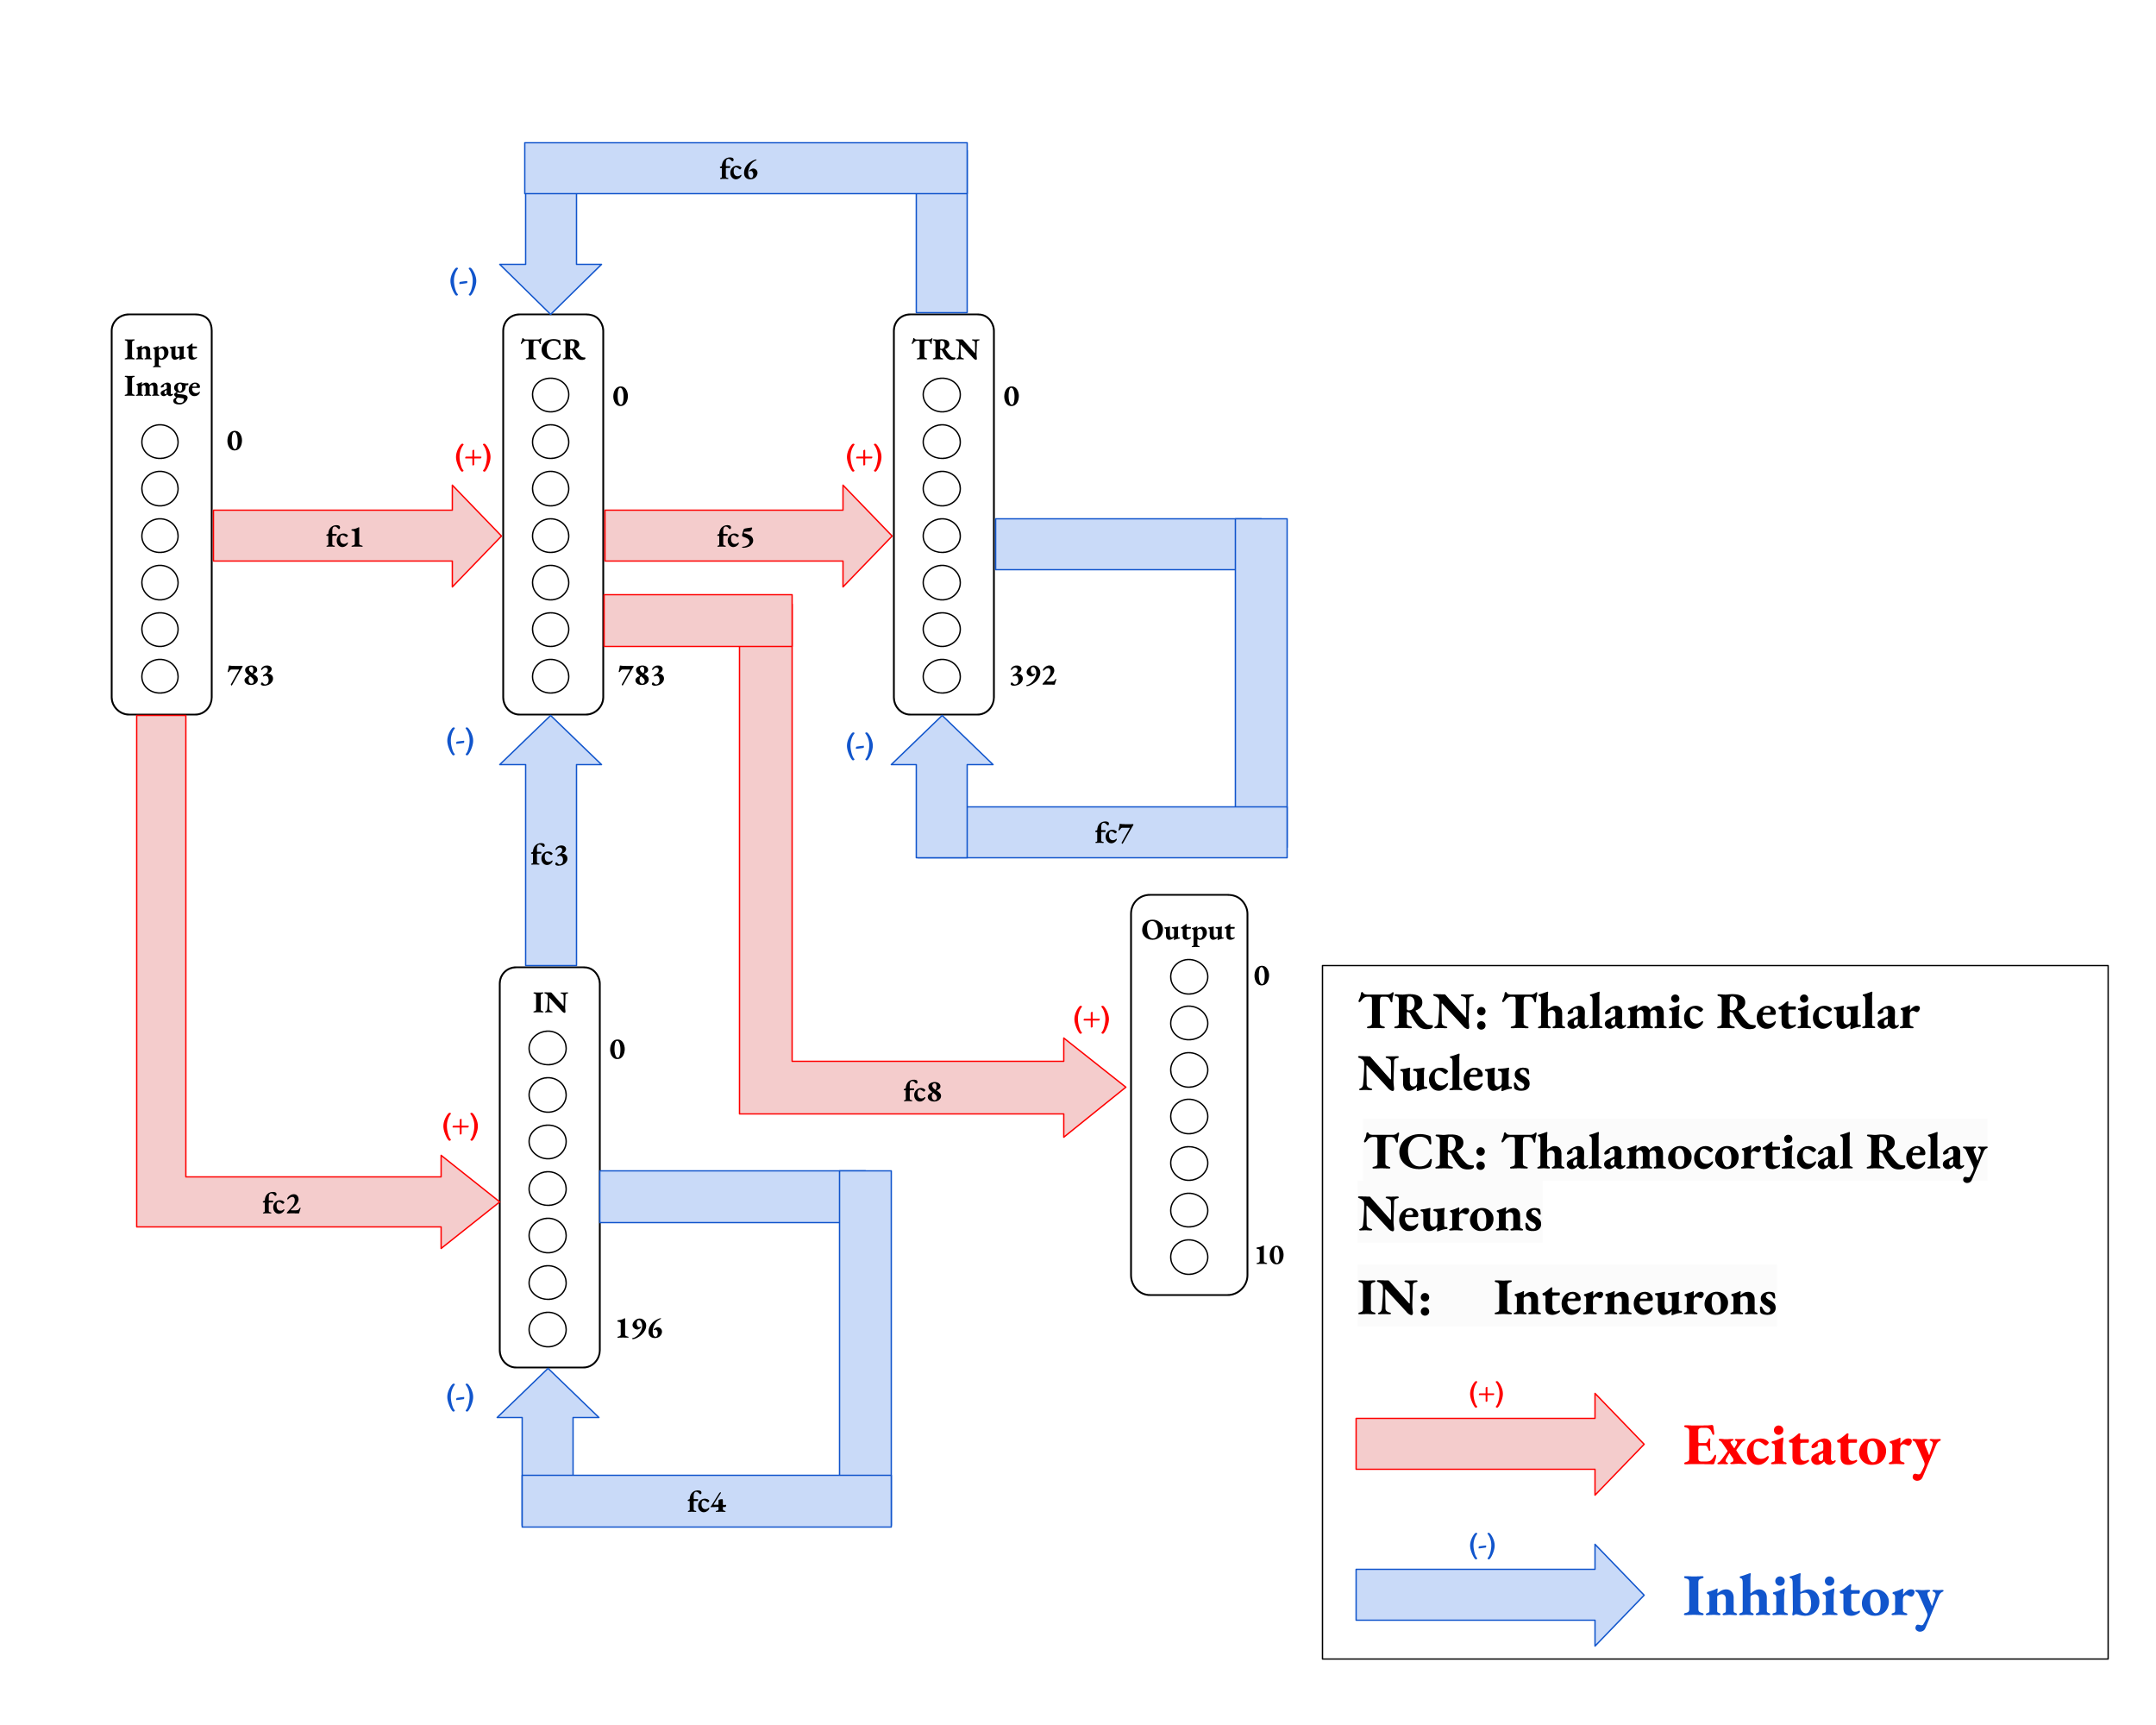

In [ ]:
duration=0.025  # Total simulation time in milliseconds (ms) i.e each iteration runs for 25ms
dt = 0.001    # A single time step is a millisecond
num_steps=int(duration/dt) # Total number of time steps is 25

##Defining the 4 neuron populations (a total of 832 neurons)

In [ ]:
input_neurons = 784  #as there are 784 pixels in an image
neurons=int(0.6*input_neurons) #Scaling the number of neurons down to 60% for sparsity, to mimic the sparsity of the brain


# Ratio TCR:TRN:IN is 4:2:1. These ratios and the nature of the neuron populations of the LGN are as per
# Sen Bhattacharya et al., “A spiking neural network model of the lateral geniculate nucleus on the SpiNNaker machine”
tcr_neurons = neurons
trn_neurons = int(neurons / 2)
in_neurons = int(neurons / 4)
output_neurons=10 # Since there are 10 output classes in the case of MNIST

##Defining the network

In [ ]:
class Net(nn.Module):
    def __init__(self, input_neurons, tcr_neurons, trn_neurons, in_neurons):
        super(Net, self).__init__()
        # Initializes layers. Performs linear transformation on input data
        # y=xW^T+b where y is output, x is input, W^T is transpose of weight matrix. Bias (b) is not included here.
        self.fc1 = nn.Linear(input_neurons,tcr_neurons, bias=False)
        self.fc2 = nn.Linear(input_neurons, in_neurons, bias=False)
        self.fc3 = nn.Linear(in_neurons, tcr_neurons, bias=False)
        self.fc4 = nn.Linear(in_neurons, in_neurons, bias=False)
        self.fc5 = nn.Linear(tcr_neurons, trn_neurons, bias=False)
        self.fc6 = nn.Linear(trn_neurons, tcr_neurons, bias=False)
        self.fc7 = nn.Linear(trn_neurons, trn_neurons, bias=False)
        self.fc8 = nn.Linear(tcr_neurons, output_neurons, bias=False)

        # Beta values of the LIFs were set heuristically. Default threshold is used i.e 1. Beta and Threshold are kept as learnable parameters.
        # Default reset mechanism i.e reset by subtraction is used, wherein every time that a spike is generated at time t, the membrane potential is set back by an amount θ at the next time instant t+1
        self.lif1 = snn.Leaky(beta=0.95, learn_beta=True, learn_threshold=True) #in
        self.lif2 = snn.Leaky(beta=0.9, learn_beta=True, learn_threshold=True) #tcr
        self.lif3 = snn.Leaky(beta=0.9, learn_beta=True, learn_threshold=True) #trn
        self.lif4 = snn.Leaky(beta=0.9, learn_beta=True, learn_threshold=True) #output

        #Initial membrane potential kept as 1
        self.mem1 = torch.ones(1)
        self.mem2 = torch.ones(1)
        self.mem3 = torch.ones(1)
        self.mem4 = torch.ones(1)
        self.spk4 = torch.ones(1)


    #FORWARD PASS
    def forward(self,flattened_images):
      spike_in=flattened_images #Plain pixel intensity values

      # Initial dummy value inputs needed for self-loop connectivities of TRN and IN
      spk2 = torch.zeros(trn_neurons)
      spk3 = torch.zeros(in_neurons)

      # Initialize tensors to store membrane potentials and spikes of output layer over time
      full_mem=torch.zeros(num_steps, batch_size, output_neurons)
      full_spk=torch.zeros(num_steps, batch_size, output_neurons)

      # Connectivities from Poisson Spike generator to network
      fc9 = nn.Linear(tcr_neurons,tcr_neurons, bias = False)
      fc10 = nn.Linear(in_neurons,in_neurons, bias = False)

      with torch.no_grad(): # Weights of Poisson connectivities are not learnable.
        # Weights are clamped such that they are strictly positive (upper limit is redundant).
        fc9.weight.data=torch.clamp(fc9.weight.data, min=0, max=1)
        fc10.weight.data=torch.clamp( fc10.weight.data, min=0, max=1)

      poisson_noise_in = input_generator(rate, in_neurons)
      poisson_noise_tcr = input_generator(rate, tcr_neurons)


      # NETWORK SIMULATION: Iterates over 128 images (1 batch) for 25 time steps (25ms) each
      for step in range(num_steps):
          # IN layer: Receives image input, self input, and noise
          cur3 = self.fc2(spike_in) + self.fc4(spk3) + fc10(poisson_noise_in)
          spk3, self.mem3 = self.lif1(cur3, self.mem3)

          # TCR layer: Receives image input, TRN and IN feedback, and noise
          cur1 = self.fc1(spike_in) + self.fc6(spk2) + self.fc3(spk3) + fc9(poisson_noise_tcr)
          spk1, self.mem1 = self.lif2(cur1, self.mem1)

          # TRN layer: Receives TCR and TRN feedback
          cur2 = self.fc5(spk1) + self.fc7(spk2)
          spk2, self.mem2 = self.lif3(cur2, self.mem2)

          # OUTPUT layer: Receives TCR input
          cur4 = self.fc8(spk1)
          self.spk4, self.mem4 = self.lif4(cur4, self.mem4)

          # Record outputs
          full_mem[step] =  self.mem4
          full_spk[step] = self.spk4

      #The shape of the recorded output will be (25,128,10) i.e (num_steps, batch size, output layer neurons). Test by uncommenting the line below.
      #print("full_mem.size:",full_mem.size())
      return full_mem, full_spk

## Instantiating model

In [ ]:
device = torch.device("cuda") # Sets the device to GPU (CUDA), assuming CUDA is available

# Instantiate model
model = Net(input_neurons, tcr_neurons, trn_neurons, in_neurons)

# Weight Clamping: To keep the weights of inhibitory connections negative and those of excitatory connections positive.
upperlim=2.0 #excitatory weights stay below 2
lowerlim=-2.0 #inhibitory weights stay above -2
mid=0.0 #excitatory weights stay above 0, inhibitory weights stay below 0

for name, param in model.named_parameters():
  if "fc3" in name or "fc4" in name  or "fc6" in name  or "fc7" in name:  #inhibitory connectivities
      param.data.clamp_(min=lowerlim, max=mid)
  elif "fc1" in name or "fc2" in name  or "fc5" in name: #excitatory connectivities
      param.data.clamp_(min=mid, max=upperlim)
  elif "fc8" in name: #tcr to output. A connectivity that's not purely excitatory showed better results.
    param.data.clamp_(min=lowerlim, max=upperlim)
  if "fc4" in name or "fc7" in name:
    param.data.fill_diagonal_(0) #Giving self-loop weight matrices zero diagonal so neurons don't receive their own output as input.

In [ ]:
#Uncomment the line below to view the initial weights
#print(f"fc1:{model.fc1.weight},\nfc2:{model.fc2.weight},\nfc3:{model.fc3.weight},\nfc4:{model.fc4.weight},\nfc5:{model.fc5.weight},\nfc6:{model.fc6.weight},\nfc7:{model.fc7.weight},\nfc8:{model.fc8.weight}")
#Uncomment the line below to save the initial weights
#torch.save(model.state_dict(), "/content/drive/My Drive/Initial.pth")

## Defining the optimizer and loss function: Adam optimizer and Cross Entropy Loss function

In [ ]:
# The Adam optimizer adaptively updates the model's parameters (weights and biases) using gradients from backpropagation to minimize the loss function during training.
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, betas=(0.9, 0.999)) # Parameters are as per snnTorch Tutorial 5: https://snntorch.readthedocs.io/en/latest/tutorials/tutorial_5.html

# Loss function, using log, measures the difference between the predicted outputs of the model and the true target values.
loss = nn.CrossEntropyLoss()

## Accuracy calculation for each iteration within an epoch

In [ ]:
def print_batch_accuracy(data, targets, train=False):
    #Forward pass
    _,output = model(data)  # Pass data to model. 'output' holds spikes (full_spk).

    _, idx = output.sum(dim=0).max(1)  # Sums up spikes over time steps, then finds the index of neuron with maximum spikes to get the predicted class.

    # Calculate accuracy by comparing predictions with actual targets.
    acc = (targets == idx).float().mean().item() # gives mean of a boolean tensor where 1=>True and 0=>False

    # Prints results as percentage
    if train:
        print(f"Train set accuracy for a single minibatch: {acc*100:.2f}%")
        accuracy_train[epoch][iter_counter] =(acc*100)
    else:
        print(f"Test set accuracy for a single minibatch: {acc*100:.2f}%")
        accuracy_test[epoch][iter_counter] =(acc*100)

##Function to display progress of training and display weights during training

In [ ]:
def train_printer(data, targets, epoch,  iter_counter, loss_hist, test_loss_hist, test_data, test_targets):
    # Prints accuracy and loss at intervals during training.
    print(f"Epoch {epoch}, Iteration {iter_counter}")
    print(f"Train Set Loss: {loss_hist[epoch][iter_counter]:.2f}")
    print(f"Test Set Loss: {test_loss_hist[epoch][iter_counter]:.2f}")

    print(f"fc1:{model.fc1.weight},\nfc2:{model.fc2.weight},\nfc3:{model.fc3.weight},\nfc4:{model.fc4.weight},\nfc5:{model.fc5.weight},\nfc6:{model.fc6.weight},\nfc7:{model.fc7.weight},\nfc8:{model.fc8.weight}")
    print("\n")

##Training Loop: Runs for 5 epochs of 380 iterations each

The training loop ends after 5 epochs as the loss curve appears to stabilize at that point.
Within each iteration we train on 128 images for 25ms each.

In [ ]:
batches= 380 # Number of batches to train on.
num_epochs = 5 # Can be varied but the loss curve appears to stabilize at 5 epochs.
num_iterations = batches

# Initializing data structures for plotting:
loss_hist = np.full((num_epochs, num_iterations), np.nan, dtype=float)
test_loss_hist = np.full((num_epochs, num_iterations), np.nan, dtype=float)
accuracy_train=np.full((num_epochs, num_iterations), np.nan, dtype=float)
accuracy_test= np.full((num_epochs, num_iterations), np.nan, dtype=float)

# TRAINING LOOP
for epoch in range(num_epochs):
    iter_counter = 0 # Local iteration counter (resets every epoch).
    train_batch = iter(train_loader)

    # Minibatch training loop
    for data, targets in train_batch: # No. of loops = No. of batches
        print(f"Epoch {epoch}, Iteration {iter_counter}:\n")
        data = data
        targets = targets
        print("data size:", data.size()) # Shape must be: [128, 1, 28, 28]
        model.train() # Set model to training mode

        # Call forward pass
        mem_rec,_ = model(data.view(batch_size, -1))
        print("mem_rec (model output) size:",mem_rec.size()) # Shape must be [25, 128, 10]
        print("targets size:", targets.size()) # Shape must be equal to batch size i.e 128

        # Training Loss
        loss_val = torch.zeros((1), dtype=dtype) # Stores loss of a batch.
        for step in range(num_steps):
            loss_val += loss(mem_rec[step], targets)

        # Backpropgation
        optimizer.zero_grad() # Clears previous gradients
        loss_val.backward() # Computes the gradients of the loss function with respect to each model parameter using autograd.

        for name, param in model.named_parameters(): # Checks for gradient errors. If either statement is printed, try varying LIF parameters.
          if param.grad is None:
              print(f"{name} gradient is None.")
          elif param.grad.norm().item()==0:
              print(f"{name} gradient norm is zero.")

        optimizer.step() # Updates model parameters based on gradients

        # Weight Clamping:
        for name, param in model.named_parameters():
          if "fc3" in name or "fc4" in name  or "fc6" in name  or "fc7" in name: # if inhibitory connection
              param.data.clamp_(min=lowerlim, max=mid)
          elif "fc1" in name or "fc2" in name  or "fc5" in name: # if excitatory connection
              param.data.clamp_(min=mid, max=upperlim)
          elif  "fc8" in name:
              param.data.clamp_(min=lowerlim, max=upperlim)
          if "fc4" in name or "fc7" in name:
              param.data.fill_diagonal_(0)

        # Stores loss history
        loss_hist[epoch][iter_counter] = loss_val.item()

        # Validation testing
        with torch.no_grad(): # Disables gradients.
            model.eval() # Sets model to testing mode
            test_data, test_targets = next(iter(test_loader)) # Tests the same batch at every iteration of the loop
            test_data = test_data
            test_targets = test_targets

            # Call forward pass
            test_mem, _ = model(test_data.view(batch_size, -1))

            # Validation Testing loss
            test_loss = torch.zeros((1), dtype=dtype)
            for step in range(num_steps):
                test_loss += loss(test_mem[step], test_targets)
            test_loss_hist[epoch][iter_counter] = test_loss.item()

            # Print train and test loss, accuracy
            print_batch_accuracy(data.view(batch_size, -1), targets, train=True)
            print_batch_accuracy(test_data.view(batch_size, -1), test_targets, train=False)
            if iter_counter==0 or iter_counter==batches*0.25 or iter_counter==batches*0.5 or iter_counter==batches*0.75 or iter_counter==batches-1: #printing weights after forward pass on last image in batch
                train_printer(data,targets,epoch,iter_counter,loss_hist,test_loss_hist,test_data, test_targets)

        print("---------------------------------------------------------------------------------------------------------------------------------------------------------------")
        iter_counter +=1
        if iter_counter==batches:
          break
    print("====================================================================================================================================================================")

Streaming output truncated to the last 5000 lines.
Test set accuracy for a single minibatch: 92.19%
---------------------------------------------------------------------------------------------------------------------------------------------------------------
Epoch 3, Iteration 216:

data size: torch.Size([128, 1, 28, 28])
mem_rec (model output) size: torch.Size([25, 128, 10])
targets size: torch.Size([128])
Train set accuracy for a single minibatch: 97.66%
Test set accuracy for a single minibatch: 92.97%
---------------------------------------------------------------------------------------------------------------------------------------------------------------
Epoch 3, Iteration 217:

data size: torch.Size([128, 1, 28, 28])
mem_rec (model output) size: torch.Size([25, 128, 10])
targets size: torch.Size([128])
Train set accuracy for a single minibatch: 92.97%
Test set accuracy for a single minibatch: 94.53%
------------------------------------------------------------------------------

## Plotting loss and accuracy of a single epoch

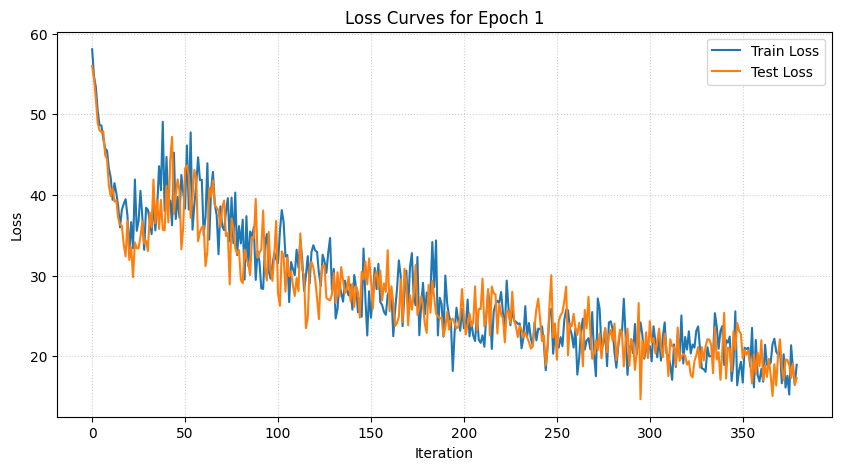

In [ ]:
# Plot train and test LOSS for a SINGLE EPOCH
epoch_idx = 0  # Index of the epoch to plot
fig = plt.figure(facecolor="w", figsize=(10, 5))
plt.plot(loss_hist[epoch_idx])
plt.plot(test_loss_hist[epoch_idx])
plt.title("Loss Curves for Epoch 1")
plt.legend(["Train Loss", "Test Loss"])
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

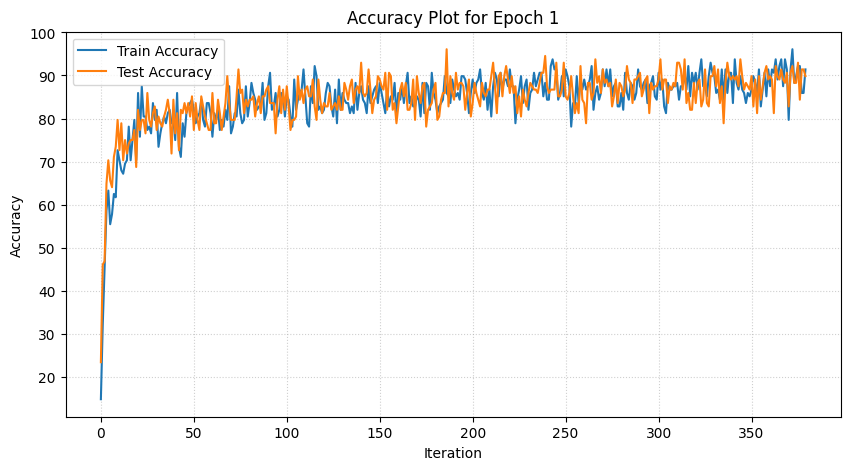

In [ ]:
# Plot train and test ACCURACY for a SINGLE EPOCH
epoch_idx = 0  # Index of the epoch to plot
fig = plt.figure(facecolor="w", figsize=(10, 5))
plt.plot(accuracy_test[epoch_idx])
plt.plot(accuracy_train[epoch_idx])
plt.title("Accuracy Plot for Epoch 1")
plt.legend(["Train Accuracy", "Test Accuracy"])
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## Plotting loss and accuracy for all epochs

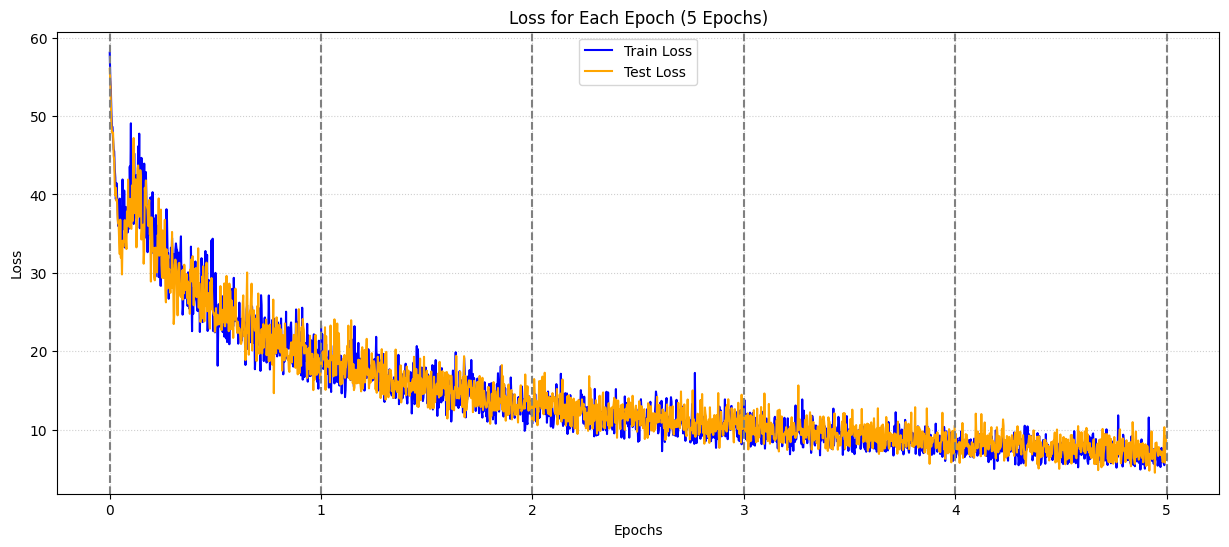

In [ ]:
# Plotting Loss
plt.figure(figsize=(15, 6))

# Plot Train Data in one color
for i in range(num_epochs):
    plt.plot(range(i * num_iterations, (i + 1) * num_iterations),
             loss_hist[i],
             color='blue')  # Fixed color for train

# Plot Test Data in another color
for i in range(num_epochs):
    plt.plot(range(i * num_iterations, (i + 1) * num_iterations),
             test_loss_hist[i],
             color='orange')  # Fixed color for test

# Add vertical grid lines for epoch boundaries
for i in range(0, num_epochs+1):
    plt.axvline(x=i * num_iterations, color='gray', linestyle='--')

plt.title(f"Loss for Each Epoch ({num_epochs} Epochs)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
epoch_ticks = [i * num_iterations for i in range(num_epochs + 1)]  # Epoch start points
epoch_labels = [f"{i}" for i in range(num_epochs + 1)]  # Labels
plt.xticks(epoch_ticks, epoch_labels)

# Legend for Train and Test
plt.plot([], [], color='blue', label='Train Loss')
plt.plot([], [], color='orange', label='Test Loss')
plt.legend()

plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

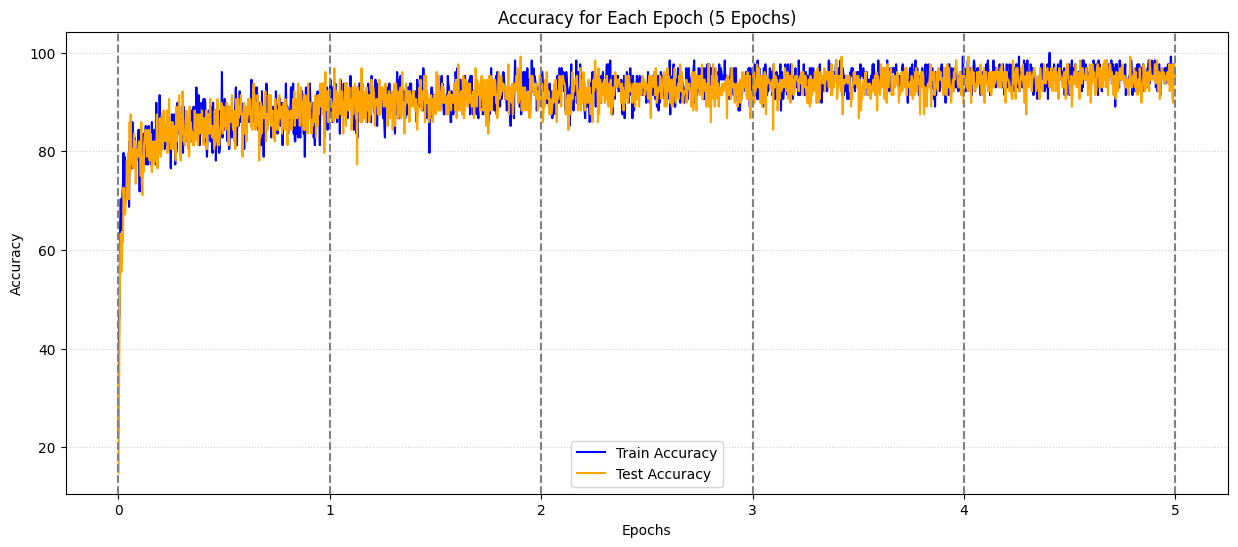

In [ ]:
# Plotting Accuracy
plt.figure(figsize=(15, 6))

# Plot Train Data in one color
for i in range(num_epochs):
    plt.plot(range(i * num_iterations, (i + 1) * num_iterations),
             accuracy_train[i],
             color='blue')  # Fixed color for train

# Plot Test Data in another color
for i in range(num_epochs):
    plt.plot(range(i * num_iterations, (i + 1) * num_iterations),
             accuracy_test[i],
             color='orange')  # Fixed color for test

# Add vertical grid lines for epoch boundaries
for i in range(0, num_epochs+1):
    plt.axvline(x=i * num_iterations, color='gray', linestyle='--')

plt.title(f"Accuracy for Each Epoch ({num_epochs} Epochs)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
epoch_ticks = [i * num_iterations for i in range(num_epochs + 1)]  # Epoch start points
epoch_labels = [f"{i}" for i in range(num_epochs + 1)]  # Labels

plt.xticks(epoch_ticks, epoch_labels)
# Legend for Train and Test
plt.plot([], [], color='blue', label='Train Accuracy')
plt.plot([], [], color='orange', label='Test Accuracy')
plt.legend()

plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## Calculating accuracy for the entire test split

In [ ]:
#Using same method of accuracy calculation, calculate accuracy of entire test set.
total = 0
correct = 0
with torch.no_grad():
  model.eval()
  for data, targets in test_loader:
    data = data
    targets = targets

    #forward pass
    _,test_spk = model(data.view(data.size(0), -1))

    #calculate accuracy
    _, predicted = test_spk.sum(dim=0).max(1)
    total += targets.size(0)
    correct += (predicted == targets).sum().item()

print(f"Total correctly classified test set images: {correct}/{total}")
print(f"Test Set Accuracy: {100 * correct / total:.2f}%")

Total correctly classified test set images: 19900/20992
Test Set Accuracy: 94.80%


## Optional: Saving final weights and other important variables to google drive

In [ ]:
checkpoint = {
    'model_state': model.state_dict(),
    'num_epochs':num_epochs,
    'num_iterations':num_iterations,
    'optimizer_state': optimizer.state_dict(),
    'accuracy_train': accuracy_train,
    'accuracy_test': accuracy_test,
    'loss_hist': loss_hist,
    'test_loss_hist': test_loss_hist,
}
#torch.save(checkpoint, "/content/drive/My Drive/Noise_Final.pth")